# 17 - Purification Policy Comparison

## Objetivo
Comparar as estratégias de purificação implementadas - o que cada uma
**estima** no planejamento e o que cada uma **executa** na rede -
variando o requisito de fidelidade em poucos valores, sobre a mesma
topologia `a - r - b`.

## Conceitos
- Uma `PurificationStrategy` (`planning/purification.py`) tem duas faces:
  `decide(...)`, a estimativa de planejamento (quantos rounds, que
  fidelidade de saída), e `execution_mode`, a política que o executor
  instala na reserva real do SeQUeNCe (`Reservation.purification_mode`).
  A decisão do plano **é executada** (`docs/physical_model.md`).

| Estratégia | Estimativa | Execução |
|---|---|---|
| `NeverPurify` | nenhum round | `never`: nenhuma regra de purificação dispara; um par abaixo do alvo é liberado |
| `PurifyOnce` | 1 round | `once`: cada par é purificado no máximo uma vez; se continuar abaixo do alvo é liberado |
| `PurifyUntilTarget` (padrão do `IntentPlanner`) | 1 round | `until_target`: purifica qualquer par abaixo do alvo, quantas vezes for preciso |
| `IterativeAnalyticalPurification` (planejador L2) | n rounds | `until_target` |

- Física (formalismo `bell_diagonal`, portas e medições ideais nesta
  topologia de demonstração): dois pares de 0.85 trocam para 0.73, e cada
  round de BBPSSW sobe um degrau - a célula de configuração imprime a
  escada. Cada tentativa consome dois pares e pode falhar.
- A fidelidade entregue é lida do estado e inclui a decoerência durante a
  espera, que nenhuma estimativa modela.

## Configuração


In [1]:
from ibqn.demos.topologies import three_node_spec
from ibqn.demos.intents import simple_intent
from ibqn.demos.planning import compare_purification_policies
from ibqn.network.capabilities import NetworkCapabilities
from ibqn.planning.planners.l2_iterative import IterativeAnalyticalPurification
from ibqn.planning.purification import NeverPurify, PurifyOnce, PurifyUntilTarget

SEED = 0
spec = three_node_spec(stop_time_s=0.2)

# The estimate ladder, from the same closed forms the planner uses: the swap-only
# fidelity, then one BBPSSW round at a time (fidelity after the round, success probability).
physics = NetworkCapabilities(spec).physics
purification = physics.purification_between("a", "b")
ladder = [physics.swap_fidelity(physics.link_fidelity("a", "r"), physics.link_fidelity("r", "b"), "r")]
print(f"swap only : {ladder[0]:.4f}")
for round_number in range(1, 5):
    success_probability, fidelity = purification.improve(ladder[-1])
    ladder.append(fidelity)
    print(f"{round_number} round(s): {fidelity:.4f}  (success probability of this round: {success_probability:.3f})")

# 0.65 : below the swap-only estimate - purification never needed.
# 0.75 : above swap-only, comfortably below the one-round estimate.
# 0.765: just under the one-round estimate - decoherence leaves part of the
#        once-purified pairs below it.
# 0.80 : needs two rounds - beyond every one-round estimate.
# 0.85 : needs four rounds.
FIDELITY_TARGETS = [0.65, 0.75, 0.765, 0.80, 0.85]

def make_intent(target):
    return simple_intent(
        intent_id=f"purif-target-{target}", source="a", destination="b",
        min_fidelity=target, requested_pairs=10, duration=0.1,
    )

policies = {
    "NeverPurify": NeverPurify(),
    "PurifyOnce": PurifyOnce(),
    "PurifyUntilTarget": PurifyUntilTarget(),
    "IterativeAnalytical": IterativeAnalyticalPurification(),
}

swap only : 0.7300
1 round(s): 0.7676  (success probability of this round: 0.705)
2 round(s): 0.8064  (success probability of this round: 0.738)
3 round(s): 0.8442  (success probability of this round: 0.775)
4 round(s): 0.8790  (success probability of this round: 0.814)


## Execução

Uma simulação real por par (alvo, estratégia) admitido no planejamento;
um plano inviável não chega ao SeQUeNCe. As duas células só dividem o
tempo de execução.

In [2]:
# targets that need at most one round
one_round_df = compare_purification_policies(spec, make_intent, policies, FIDELITY_TARGETS[:3], seed=SEED)
one_round_df

2026-10-02 15:04:10,094 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'requested_pairs' -> 'reserved_memory_slots' (see docs/intent_resource_semantics.md)


2026-10-02 15:04:10,095 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'start_time' -> 'start_time_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:04:10,097 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'duration' -> 'duration_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:04:10,099 INFO     ibqn.ibqn.planning.planner intent_id=purif-target-0.65 - planned route a->r->b, estimated_fidelity=0.7300, purification=False


2026-10-02 15:04:10,108 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - topology built: 3 routers, 2 quantum links, formalism=bell_diagonal, seed=0


...

2026-10-02 15:04:58,897 INFO     ibqn.ibqn.experiments.runner intent_id=- - running scenario 'IterativeAnalytical-0.765', seed=0, 1 intent(s)


2026-10-02 15:04:58,898 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.200s


2026-10-02 15:04:58,900 INFO     ibqn.ibqn.intent.repository intent_id=purif-target-0.765 - intent transitioned to ACTIVE (reservation approved)


2026-10-02 15:05:03,704 INFO     ibqn.ibqn.intent.repository intent_id=purif-target-0.765 - intent transitioned to SATISFIED (all success conditions met)


,min_fidelity,policy,requires_purification,rounds_estimate,estimated_fidelity,execution_mode,feasible,final_status,observed_delivered_pairs,observed_average_fidelity,discarded_pairs
0,0.650,NeverPurify,False,0.0,0.7300,never,True,SATISFIED,665.0,0.7288,0.0
1,0.650,PurifyOnce,False,0.0,0.7300,once,True,SATISFIED,665.0,0.7288,0.0
2,0.650,PurifyUntilTarget,False,0.0,0.7300,until_target,True,SATISFIED,665.0,0.7288,0.0
3,0.650,IterativeAnalytical,False,0.0,0.7300,until_target,True,SATISFIED,665.0,0.7288,0.0
4,0.750,NeverPurify,False,NaN,NaN,NaN,False,REJECTED,NaN,NaN,NaN
5,0.750,PurifyOnce,True,1.0,0.7676,once,True,SATISFIED,179.0,0.7659,0.0
6,0.750,PurifyUntilTarget,True,1.0,0.7676,until_target,True,SATISFIED,179.0,0.7659,0.0
7,0.750,IterativeAnalytical,True,1.0,0.7676,until_target,True,SATISFIED,179.0,0.7659,0.0
8,0.765,NeverPurify,False,NaN,NaN,NaN,False,REJECTED,NaN,NaN,NaN
9,0.765,PurifyOnce,True,1.0,0.7676,once,True,SATISFIED,172.0,0.7659,7.0


In [3]:
import pandas as pd

# targets that need two and four rounds: only the iterative estimate admits them
multi_round_df = compare_purification_policies(spec, make_intent, policies, FIDELITY_TARGETS[3:], seed=SEED)
comparison_df = pd.concat([one_round_df, multi_round_df], ignore_index=True)
multi_round_df

2026-10-02 15:05:03,757 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'requested_pairs' -> 'reserved_memory_slots' (see docs/intent_resource_semantics.md)


2026-10-02 15:05:03,759 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'start_time' -> 'start_time_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:05:03,760 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'duration' -> 'duration_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:05:03,761 INFO     ibqn.ibqn.planning.planner intent_id=purif-target-0.8 - planning failed: no candidate route is feasible: a->r->b (min_fidelity 0.800 exceeds the achievable estimate 0.730 (never-purify baseline strategy))


2026-10-02 15:05:03,763 INFO     ibqn.ibqn.planning.planner intent_id=purif-target-0.8 - planning failed: no candidate route is feasible: a->r->b (min_fidelity 0.800 exceeds the achievable estimate 0.768 (one-round static estimate; executed as SeQUeNCe's 'once' mode (each pair purified at most one time)))


...

2026-10-02 15:05:08,392 INFO     ibqn.ibqn.experiments.runner intent_id=- - running scenario 'IterativeAnalytical-0.85', seed=0, 1 intent(s)


2026-10-02 15:05:08,393 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.200s


2026-10-02 15:05:08,394 INFO     ibqn.ibqn.intent.repository intent_id=purif-target-0.85 - intent transitioned to ACTIVE (reservation approved)


2026-10-02 15:05:13,040 INFO     ibqn.ibqn.intent.repository intent_id=purif-target-0.85 - intent transitioned to VIOLATED (delivered_pairs >= 10.0 (observed=0.0) -> FAIL; average_fidelity >= 0.85 (observed=None) -> FAIL)


,min_fidelity,policy,requires_purification,rounds_estimate,estimated_fidelity,execution_mode,feasible,final_status,observed_delivered_pairs,observed_average_fidelity,discarded_pairs
0,0.80,NeverPurify,False,NaN,NaN,NaN,False,REJECTED,NaN,NaN,NaN
1,0.80,PurifyOnce,False,NaN,NaN,NaN,False,REJECTED,NaN,NaN,NaN
2,0.80,PurifyUntilTarget,False,NaN,NaN,NaN,False,REJECTED,NaN,NaN,NaN
3,0.80,IterativeAnalytical,True,2.0,0.8064,until_target,True,SATISFIED,29.0,0.8075,0.0
4,0.85,NeverPurify,False,NaN,NaN,NaN,False,REJECTED,NaN,NaN,NaN
5,0.85,PurifyOnce,False,NaN,NaN,NaN,False,REJECTED,NaN,NaN,NaN
6,0.85,PurifyUntilTarget,False,NaN,NaN,NaN,False,REJECTED,NaN,NaN,NaN
7,0.85,IterativeAnalytical,True,4.0,0.8790,until_target,True,VIOLATED,0.0,NaN,0.0


## Resultados


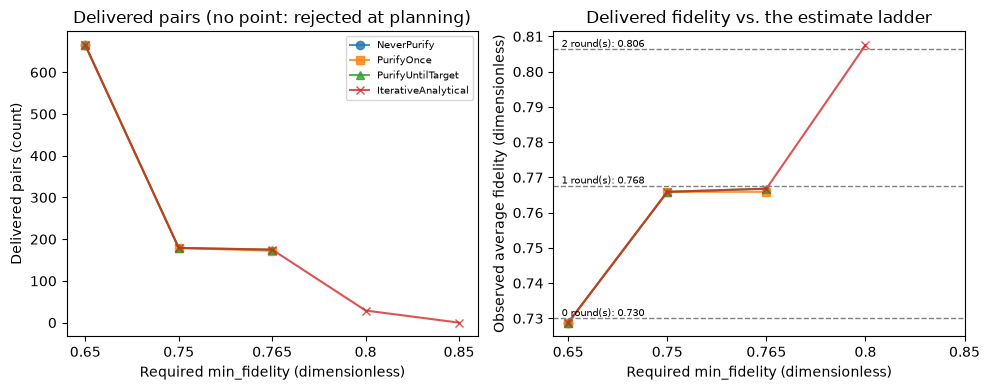

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
positions = {target: i for i, target in enumerate(FIDELITY_TARGETS)}
markers = {"NeverPurify": "o", "PurifyOnce": "s", "PurifyUntilTarget": "^", "IterativeAnalytical": "x"}

for policy_name in policies:
    subset = comparison_df[(comparison_df["policy"] == policy_name) & comparison_df["feasible"]]
    x = [positions[target] for target in subset["min_fidelity"]]
    axes[0].plot(x, subset["observed_delivered_pairs"], marker=markers[policy_name], alpha=0.8, label=policy_name)
    axes[1].plot(x, subset["observed_average_fidelity"], marker=markers[policy_name], alpha=0.8, label=policy_name)

for ax in axes:
    ax.set_xticks(list(positions.values()))
    ax.set_xticklabels([str(target) for target in FIDELITY_TARGETS])
    ax.set_xlabel("Required min_fidelity (dimensionless)")

axes[0].set_ylabel("Delivered pairs (count)")
axes[0].set_title("Delivered pairs (no point: rejected at planning)")
axes[0].legend(fontsize=7)

axes[1].set_ylabel("Observed average fidelity (dimensionless)")
axes[1].set_title("Delivered fidelity vs. the estimate ladder")
for rounds, fidelity in enumerate(ladder[:3]):
    axes[1].axhline(fidelity, color="gray", linestyle="--", linewidth=1)
    axes[1].annotate(f"{rounds} round(s): {fidelity:.3f}", (0.02, fidelity), xycoords=("axes fraction", "data"),
                     fontsize=7, va="bottom")

fig.tight_layout()
plt.show()

In [5]:
def row(target, policy):
    return comparison_df[(comparison_df["min_fidelity"] == target) & (comparison_df["policy"] == policy)].iloc[0]

# below the swap-only estimate nobody purifies, and the four strategies run the same thing
below = comparison_df[comparison_df["min_fidelity"] == 0.65]
assert not below["requires_purification"].any()
assert below["observed_delivered_pairs"].nunique() == 1

# above it, NeverPurify is rejected at planning and the purifying strategies deliver fewer, better pairs
assert bool(row(0.75, "NeverPurify")["feasible"]) is False, "NeverPurify must be rejected at 0.75 (above the swap-only estimate)"
purified = row(0.75, "PurifyUntilTarget")
assert bool(purified["feasible"]) is True and bool(purified["requires_purification"]) is True
assert purified["observed_delivered_pairs"] < row(0.65, "PurifyUntilTarget")["observed_delivered_pairs"]
assert purified["observed_average_fidelity"] > row(0.65, "PurifyUntilTarget")["observed_average_fidelity"]

# the executed mode is the plan's: 'once' releases the pairs one round left short, 'until_target' purifies them again
once, until_target = row(0.765, "PurifyOnce"), row(0.765, "PurifyUntilTarget")
assert once["execution_mode"] == "once" and until_target["execution_mode"] == "until_target"
assert once["discarded_pairs"] > 0 and until_target["discarded_pairs"] == 0

# beyond one round only the iterative estimate admits the intent
for target in (0.80, 0.85):
    assert bool(row(target, "PurifyUntilTarget")["feasible"]) is False, "a one-round estimate rejects a multi-round target"
    assert bool(row(target, "IterativeAnalytical")["feasible"]) is True
assert row(0.80, "IterativeAnalytical")["final_status"] == "SATISFIED"
assert row(0.85, "IterativeAnalytical")["final_status"] == "VIOLATED", "four rounds do not fit this window"
print("Confirmed: the plan's purification policy is the one executed; every extra round costs pairs; "
      "a fidelity estimate alone does not say whether the window can pay for the rounds it predicts.")

Confirmed: the plan's purification policy is the one executed; every extra round costs pairs; a fidelity estimate alone does not say whether the window can pay for the rounds it predicts.


## Interpretação
- **0.65** (abaixo do swap isolado): nenhuma estratégia purifica e as
  quatro execuções são idênticas - a rede entrega o mesmo número de pares,
  com fidelidade média logo abaixo da estimativa de swap (os pares
  decoerem enquanto esperam o segundo enlace).
- **0.75** (acima do swap isolado, abaixo da estimativa de um round):
  `NeverPurify` é rejeitado antes de tocar o SeQUeNCe; as demais purificam
  uma vez e entregam o intent, com cerca de um quarto dos pares - cada
  round consome dois pares e falha em cerca de 30% das tentativas.
- **0.765** (logo abaixo da estimativa de um round): a estimativa admite
  o intent, mas parte dos pares purificados decoere para baixo do alvo
  antes da entrega. `once` libera esses pares (coluna `discarded_pairs`);
  `until_target` os purifica de novo. A mesma estimativa, duas execuções
  diferentes: a política do plano é de fato a executada.
- **0.80** (dois rounds): as estratégias de estimativa de um round
  rejeitam o intent, embora a rede, executando `until_target`, o
  satisfaça - a falsa rejeição do "teto de um round"
  (`docs/false_rejection_root_cause.md`). A estimativa iterativa o admite
  e ele é satisfeito, com poucos pares.
- **0.85** (quatro rounds): a estimativa iterativa admite o intent - a
  escada de fidelidade chega lá -, mas nenhum par é entregue na janela:
  `VIOLATED`. A estimativa está certa sobre fidelidade e não diz nada
  sobre o custo em pares e tempo, a limitação que os planejadores cientes
  de recursos atacam (`docs/realistic_results.md`).

## Limitações
- Portas e medições ideais: com as fidelidades de porta demonstradas em
  laboratório um round de BBPSSW não eleva a fidelidade de um par já
  trocado, e a melhor política é não purificar
  (`docs/parameter_calibration.md`; campanha R03 em
  `docs/realistic_results.md`).
- Uma seed por célula: os números ilustram o mecanismo, não são uma
  estatística (a campanha R03 usa 20 seeds por célula).
- O SeQUeNCe purifica cada estágio até o alvo antes do swap seguinte
  (enlaces, depois o par fim a fim); as estimativas modelam "swap, depois
  purificação fim a fim" (`docs/physical_model.md`).

## Conclusão
A política de purificação é uma decisão do plano que a rede executa:
purificar estende a faixa de fidelidade alcançável, cada round custa
pares, e uma estimativa de fidelidade sozinha não garante que a janela
comporte os rounds que ela mesma prevê.